<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 3 — Filtros FIR, IIR y Transformada Z</font></h1>
<br>
<br>
<div style="text-align:right">
<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>
<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Nivel: 7.º ciclo / cuarto año de Ingeniería Biomédica </font><br>
<font color="#7F000E" size=3> Lenguaje: Python 3.x | Entorno: Jupyter Notebook / VS Code </font><br>
</div>

---

### **Objetivo**

El objetivo de este laboratorio no es memorizar funciones de Python. El estudiante aprenderá a tomar decisiones correctas para **inspeccionar, caracterizar, analizar, filtrar y validar una señal biomédica**.

**Flujo de trabajo:**

> Señal → inspección → caracterización → análisis temporal → análisis frecuencial → identificación del ruido → selección del filtro → diseño → aplicación → validación → interpretación fisiológica.

> **Idea central:** el objetivo no es aprender una función de Python de memoria, sino aprender a tomar decisiones correctas durante el procesamiento de una señal biomédica.

## 1. Objetivos de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:

1. Analizar una señal biomédica en el dominio temporal.
2. Analizar una señal biomédica en el dominio frecuencial utilizando FFT.
3. Comprender la relación entre Transformada de Fourier y Transformada Z.
4. Diseñar y aplicar filtros FIR e IIR.
5. Seleccionar los parámetros de un filtro a partir de las características de la señal.
6. Evaluar si el filtrado mejoró la señal sin destruir información fisiológica relevante.

## 2. Entorno computacional

Se utilizarán:

- Python 3.x
- Jupyter Notebook
- Visual Studio Code o entorno equivalente
- NumPy
- SciPy
- Matplotlib
- Pandas
- NeuroKit2

### Instalación recomendada con UV

Desde una terminal:

```bash
uv venv
```

Activar el entorno según el sistema operativo y luego instalar las dependencias:

```bash
uv pip install numpy scipy matplotlib pandas neurokit2 jupyter
```

Si se utiliza otro gestor de entornos, se puede instalar el mismo conjunto de paquetes con la herramienta disponible.

## 3. Fundamentos teóricos

### 3.1 Señal discreta

Una señal discreta puede representarse como:

$$x[n]$$

donde $n$ representa el índice de muestra. Si la frecuencia de muestreo es $f_s$, el periodo de muestreo es:

$$T_s = \frac{1}{f_s}$$

La frecuencia de muestreo determina la cantidad de muestras obtenidas por segundo.

### 3.2 Transformada de Fourier

La señal puede estudiarse en dos dominios:

- **Temporal:** permite observar cómo cambia la amplitud con el tiempo.
- **Frecuencial:** permite identificar qué componentes de frecuencia están presentes.

La DFT se expresa como:

$$X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}$$

La FFT es un algoritmo eficiente para calcular la DFT.

Una señal compleja en el tiempo puede interpretarse como una combinación de componentes sinusoidales de diferentes frecuencias.

### 3.3 Transformada Z

La Transformada Z se define, de manera general, como:

$$X(z)=\sum_{n=-\infty}^{\infty}x[n]z^{-n}$$

La variable $z$ es compleja. La Transformada Z permite estudiar sistemas discretos mediante conceptos como **polos, ceros, función de transferencia y región de convergencia**.

Para un sistema:

$$H(z)=\frac{Y(z)}{X(z)}=\frac{B(z)}{A(z)}$$

### 3.4 Relación Fourier–Z

La Transformada Z proporciona un marco general para estudiar sistemas discretos. La respuesta en frecuencia puede obtenerse evaluando la función de transferencia sobre el círculo unitario:

$$z=e^{j\omega}$$

Por tanto:

> **Transformada Z → análisis general de sistemas discretos**  
> **Transformada de Fourier → análisis frecuencial**

### 3.5 Filtros FIR

Un filtro FIR (Finite Impulse Response) puede expresarse mediante:

$$y[n]=\sum_{k=0}^{M}b[k]x[n-k]$$

No utiliza realimentación. Sus coeficientes determinan la respuesta del filtro. Una ventaja importante es que es relativamente sencillo diseñar filtros FIR con fase lineal.

### 3.6 Filtros IIR

Un filtro IIR (Infinite Impulse Response) utiliza realimentación. Conceptualmente:

$$H(z)=\frac{B(z)}{A(z)}$$

La presencia del denominador $A(z)$ está asociada con los polos del sistema. Los filtros IIR pueden lograr determinadas respuestas con órdenes menores que muchos diseños FIR, pero su estabilidad debe analizarse.

## 4. Herramientas y señal ECG

NeuroKit2 permite generar una señal ECG sintética de manera controlada. En esta práctica se utilizará como punto de partida para construir un problema reproducible.

Parámetros de ejemplo:

- duración = 10 s
- frecuencia de muestreo = 250 Hz
- frecuencia cardíaca = 70 bpm

In [4]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 49.5 MB/s eta 0:00:00


In [5]:
!uv pip install numpy scipy matplotlib pandas neurokit2 jupyter


Using Python 3.13.15 environment at: /usr
Resolved 113 packages in 1.14s
Prepared 9 packages in 1.15s
Installed 9 packages in 379ms
 + async-lru==2.3.0
 + jedi==0.20.0
 + json5==0.15.0
 + jupyter==1.1.1
 + jupyter-builder==1.2.2
 + jupyter-lsp==2.3.1
 + jupyterlab==4.6.3
 + jupyterlab-server==2.28.0
 + neurokit2==0.2.13


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import neurokit2 as nk

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


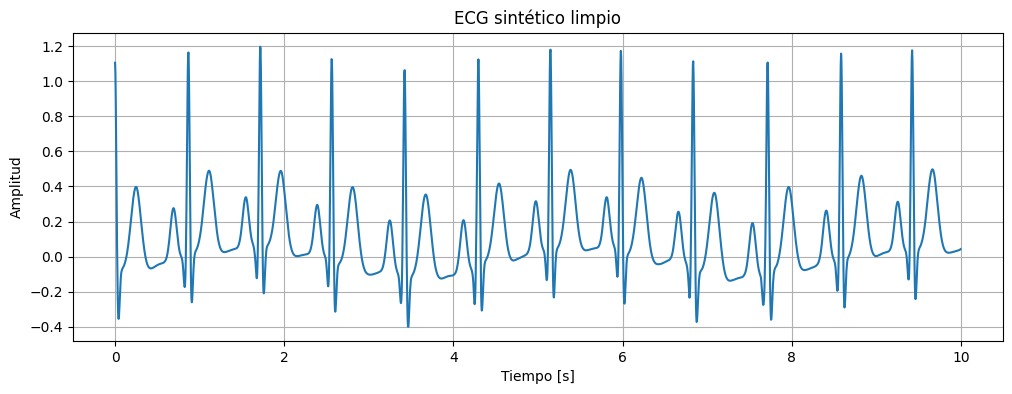

In [7]:
# Generación de una señal ECG sintética
duration = 10
sampling_rate = 250
heart_rate = 70

ecg_clean = nk.ecg_simulate(
    duration=duration,
    sampling_rate=sampling_rate,
    heart_rate=heart_rate
)

t = np.arange(len(ecg_clean)) / sampling_rate

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_clean)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG sintético limpio")
plt.grid(True)
plt.show()

### Actividad inicial

Antes de continuar, responde:

1. ¿Cuál es la frecuencia de muestreo?
2. ¿Cuántas muestras contiene la señal?
3. ¿Cuál es su duración?
4. ¿Qué elementos de la morfología ECG puedes reconocer?
5. ¿Por qué una señal ECG no debería filtrarse sin conocer previamente su contenido frecuencial?

In [9]:
# Respuesta - Actividad inicial (cálculo de las características básicas de la señal)
print(f"Frecuencia de muestreo (fs): {sampling_rate} Hz")
print(f"Número de muestras (N): {len(ecg_clean)}")
print(f"Duración: {len(ecg_clean)/sampling_rate:.2f} s")

Frecuencia de muestreo (fs): 250 Hz
Número de muestras (N): 2500
Duración: 10.00 s


### Respuesta — Actividad inicial

1. **Frecuencia de muestreo:** f_s = 250 Hz.
2. **Número de muestras:** N = 2500 muestras.
3. **Duración:** 10.00 s.
4. **Morfología reconocible:** en cada ciclo cardíaco se distinguen la onda P, el complejo QRS y la onda T, tambien podemos ver a partir de la cantidad de picos en un determinado tiempo, para poder saber su frecuencia apartir de la grafica, por ejemplo, en 6 segundos podemos ver 7 picos lo cual significa que la señal tiene un bpm de 70, teniendo en cuenta que cada 0.86s se ecuentra un pico.
5. **Por qué no filtrar sin conocer el contenido frecuencial:** Si queremos filtrar sin reconocer el contenido frecuencial se corre el peligro de eliminar contenido de nuestra señal ¨sana¨, hasta podriamos por error dejar pasar el ruido, por lo que debemos de siempre reconocer este, se puede reconocer sencillamente viendo el ECG





# EJERCICIO 1 — ANÁLISIS Y CARACTERIZACIÓN DE LA SEÑAL

## Competencia

Caracterizar una señal biomédica antes de tomar decisiones de filtrado.

En una aplicación real, la señal puede provenir de un archivo:

```text
senal_biomedica.wav
```

Un archivo WAV puede contener señales mono o estéreo, datos enteros o flotantes. Por ello, antes de procesarlo debes inspeccionar su formato.

### Si recibes un WAV

Utiliza:

```python
from scipy.io import wavfile
fs, data = wavfile.read("senal_biomedica.wav")
```

**No asumas** el tipo de dato, número de canales ni frecuencia de muestreo.

In [ ]:
# Plantilla para inspeccionar un archivo WAV.
# Completa los elementos indicados.

# fs, data = wavfile.read("senal_biomedica.wav")

# print("Frecuencia de muestreo:", ...)
# print("Número de muestras:", ...)
# print("Shape:", ...)
# print("Tipo de dato:", ...)
# print("Duración [s]:", ...)

In [10]:
# Respuesta - Inspección robusta de un archivo WAV (o señal ECG como respaldo)
import os

wav_path = "senal_biomedica.wav"

if os.path.exists(wav_path):
    fs_wav, data_wav = wavfile.read(wav_path)
    data_wav = np.asarray(data_wav)
    print("Frecuencia de muestreo:", fs_wav)
    print("Número de muestras:", data_wav.shape[0])
    print("Shape:", data_wav.shape)
    print("Tipo de dato:", data_wav.dtype)
    print("Duración [s]:", data_wav.shape[0] / fs_wav)
    if data_wav.ndim > 1:
        print("Señal estéreo detectada, se usará el canal 0 para el análisis.")
        data_wav = data_wav[:, 0]
    x_signal = data_wav.astype(float)
    fs = fs_wav
else:
    print("No se encontró 'senal_biomedica.wav'; se utilizará la señal ECG sintética como respaldo.")
    x_signal = np.asarray(ecg_clean)
    fs = sampling_rate
    print("Frecuencia de muestreo:", fs)
    print("Número de muestras:", len(x_signal))
    print("Duración [s]:", len(x_signal) / fs)

No se encontró 'senal_biomedica.wav'; se utilizará la señal ECG sintética como respaldo.
Frecuencia de muestreo: 250
Número de muestras: 2500
Duración [s]: 10.0


### Trabajo solicitado

1. Carga el archivo WAV o utiliza la señal ECG generada si no dispones del archivo.
2. Identifica la frecuencia de muestreo.
3. Obtén el número de muestras.
4. Calcula la duración.
5. Grafica la señal en el dominio temporal.
6. Calcula la FFT.
7. Grafica el espectro de magnitud.
8. Identifica las principales componentes frecuenciales.
9. Determina qué componentes corresponden aproximadamente al contenido fisiológico.
10. Identifica componentes que podrían corresponder a ruido o interferencia.

### Completa el siguiente esquema

```python
fs = 250
#La frecuencia de muestreo

N = 2500
#Numero de muestras de la señal
```

No copies una solución. Completa cada variable justificando qué representa.

Frecuencia de muestreo: 250 Hz
Número de muestras: 2500
Duración: 10.00 s


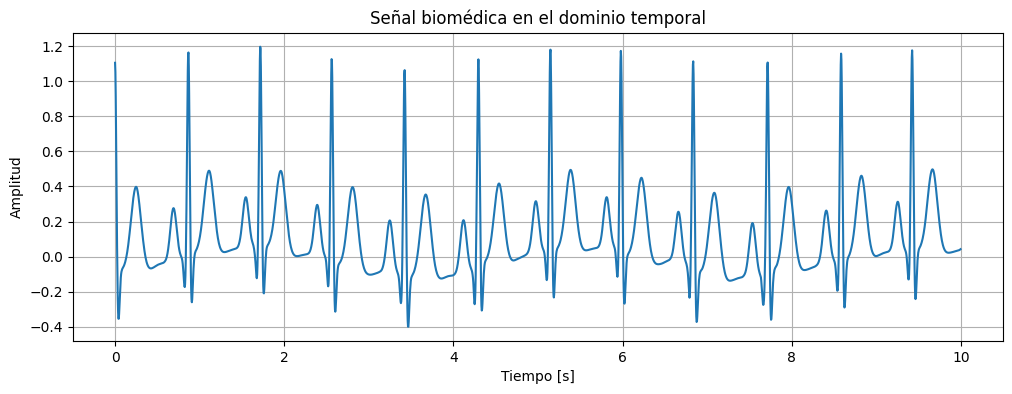

In [23]:
# Análisis temporal: completa o adapta este bloque.
fs = sampling_rate #Frecuencia de sampleo
x = np.asarray(ecg_clean)

N = len(x) #Numero de muestras de la señal
duration_signal = N / fs #Duración de la señal a partir de tiempo de muestreo = 1/fs, multiplicado por el numero de muestras

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de muestras: {N}")
print(f"Duración: {duration_signal:.2f} s")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(N) / fs, x)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal biomédica en el dominio temporal")
plt.grid(True)
plt.show()

In [ ]:
# FFT: el estudiante debe completar/explicar cada paso.
# Pista: utiliza np.fft.rfft y np.fft.rfftfreq.

# frequencies = ...
# fft_signal = ...
# magnitude = ...

# plt.figure(figsize=(12, 4))
# plt.plot(frequencies, magnitude)
# plt.xlabel("Frecuencia [Hz]")
# plt.ylabel("Magnitud")
# plt.title("Espectro de magnitud")
# plt.grid(True)
# plt.show()

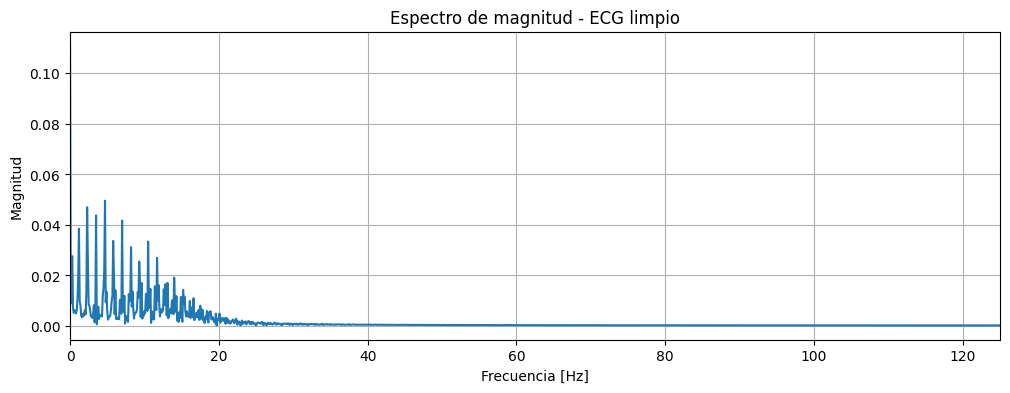

Componentes de frecuencia dominantes:
  4.70 Hz -> magnitud 0.04960
  2.30 Hz -> magnitud 0.04701
  3.50 Hz -> magnitud 0.04377
  7.00 Hz -> magnitud 0.04173
  1.20 Hz -> magnitud 0.03852
  5.80 Hz -> magnitud 0.03369
  10.50 Hz -> magnitud 0.03342
  8.20 Hz -> magnitud 0.03121


In [12]:
# Respuesta - FFT de la señal
N = len(x)
frequencies = np.fft.rfftfreq(N, d=1/fs) #Esta funcion generara todos los valores del eje de frecuencias, lo hace a partir del numero de muestras y el periodo de muestreo
fft_signal = np.fft.rfft(x) #Pasa la señal del dominio del tiempo al dominio de la frecuencia
magnitude = np.abs(fft_signal) / N #Esta funcion genera los valores del eje de magnitud

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG limpio")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Componentes dominantes (excluyendo DC)
idx_sorted = np.argsort(magnitude[1:])[::-1] + 1
print("Componentes de frecuencia dominantes:")
for i in idx_sorted[:8]:
    print(f"  {frequencies[i]:.2f} Hz -> magnitud {magnitude[i]:.5f}")

### Preguntas de análisis — Ejercicio 1

Responde con argumentos técnicos:

1. ¿Qué frecuencias predominan?
2. ¿Qué frecuencia parece corresponder al contenido fisiológico?
3. ¿Qué frecuencia podría corresponder a ruido?
4. ¿Qué frecuencia de corte propondrías?
5. ¿Por qué?
6. ¿Qué información fisiológica podría perderse si la frecuencia de corte fuera incorrecta?
7. ¿Qué relación existe entre $f_s$ y la frecuencia máxima observable?

### Respuesta — Preguntas de análisis (Ejercicio 1)
1. **Frecuencias que predominan:** Podemos ver multiples picos, con una magnitud mayor a comparacion del resto de la señal en 1.2, 2.3, 3.5, 4.7, 5.8, 7.0, 10.5 y 8.2 Hz, estas frecuencias serian las predominantes.
2. **Frecuencia fisiológica:** Podemos interpretar como la señal relevante a toda la informacion anterior a 40Hz, debido a que la frecuncia de esta ECG fue de 70bpm, podemos ver una componente de 1.17Hz, aproximadamente 1.2Hz, por ello todos los demas picos vendrian a ser sus armonicos.
3. **Frecuencia de posible ruido:** Podemos observar que la señal proporcionada esta limpia, pero en caso de no ser ese, podriamos asumir que las anomalias aparezcan a partir de los 40Hz para adelante, siendo esto ruido de alta frecuencia.
4. **Frecuencia de corte propuesta:** Podriamos usar una frecuencia de corte de 40Hz, para filtros pasa-bajas
5. **Justificación:** La señal contien la mayor parte de su energía por debajo de 40 Hz, cortar en 40Hz conservaria la morfología del ECG y atenuaria componentes de alta frecuencia que normalmente son ruido.
6. **Riesgo de un corte incorrecto:** un corte muy bajo nos haria perder informacion fisiologica o relevanta, mientras que un corte muy alto deja pasar ruido sin cumplir su función.
7. **Relación $f_s$ y frecuencia máxima observable:** por el teorema de Nyquist, la máxima frecuencia representable sin aliasing es $f_s/2 = 125$ Hz.



# EJERCICIO 2 — DISEÑO Y COMPARACIÓN DE FILTROS FIR E IIR

## Competencia

Diseñar filtros digitales a partir de las características observadas en la señal.

Utiliza `scipy.signal`. Algunas herramientas disponibles son:

- `firwin`
- `butter`
- `cheby1`
- `cheby2`
- `freqz`
- `sosfilt`
- `sosfiltfilt`
- `sosfreqz`

**No se entrega una implementación completa.** Debes seleccionar y justificar:

- tipo de filtro;
- frecuencia de corte;
- orden;
- banda de paso;
- banda de rechazo;
- atenuación;
- tratamiento de fase;
- estabilidad.

### Parte A — Diseño FIR

Selecciona un filtro FIR utilizando `firwin`.

Esqueleto orientativo:

```python
numtaps = ...
cutoff = ...

b_fir = signal.firwin(
    numtaps=...,
    cutoff=...,
    fs=...
)

a_fir = ...
```

Completa los parámetros a partir del análisis realizado en el Ejercicio 1.

In [ ]:
# Completa este bloque.
# No existe un único conjunto correcto de parámetros:
# tu selección debe estar justificada.

# numtaps = ...
# cutoff_fir = ...
#
# b_fir = signal.firwin(
#     numtaps=numtaps,
#     cutoff=cutoff_fir,
#     fs=fs
# )
# a_fir = np.array([1.0])

In [13]:
# Respuesta - Diseño de filtro FIR (pasa-bajos)
numtaps = 101 #Numero de coeficientes que se usaran para este FIR
cutoff_fir = 40.0 #Frecuencia de corte

b_fir = signal.firwin(
    numtaps=numtaps,
    cutoff=cutoff_fir,
    fs=fs
)
a_fir = np.array([1.0])

print(f"Filtro FIR pasa-bajos: numtaps={numtaps}, cutoff={cutoff_fir} Hz")
print("Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T")
print("(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).")
print(f"Con {numtaps} taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.")

Filtro FIR pasa-bajos: numtaps=101, cutoff=40.0 Hz
Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T
(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).
Con 101 taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.


### Parte B — Diseño IIR

Diseña un filtro IIR. Puedes utilizar Butterworth o, si justificas la elección, Chebyshev.

Ejemplo parcial:

```python
order = ...
cutoff = ...

b_iir, a_iir = signal.butter(
    N=...,
    Wn=...,
    btype="...",
    fs=...
)
```

Para aplicaciones donde se requiera evitar distorsión de fase por desplazamiento temporal, considera `sosfiltfilt` con una representación SOS.

In [14]:
# Completa este bloque.
# Justifica el orden y la frecuencia de corte.

# order_iir = ...
# cutoff_iir = ...
#
# sos_iir = signal.butter(
#     N=...,
#     Wn=...,
#     btype="lowpass",
#     fs=fs,
#     output="sos"
# )

In [15]:
# Respuesta - Diseño de filtro IIR (Butterworth pasa-bajos, forma SOS)
order_iir = 4 #Numero de coeficientes que se usara en este IIR
cutoff_iir = 40.0 #Frecuencia de corte

sos_iir = signal.butter(
    N=order_iir,
    Wn=cutoff_iir,
    btype="lowpass",
    fs=fs,
    output="sos"
)

print(f"Filtro IIR Butterworth: orden={order_iir}, cutoff={cutoff_iir} Hz")
print("Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica")
print("frente a la forma (b,a) en filtros de orden alto.")
print("Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal")
print("que introduciría un filtro IIR aplicado en un solo sentido.")

Filtro IIR Butterworth: orden=4, cutoff=40.0 Hz
Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica
frente a la forma (b,a) en filtros de orden alto.
Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal
que introduciría un filtro IIR aplicado en un solo sentido.


### Parte C — Aplicación y comparación

Aplica ambos filtros y grafica:

1. señal original;
2. señal filtrada FIR;
3. señal filtrada IIR.

Después calcula y grafica sus respuestas en frecuencia.

Utiliza `freqz` para el FIR y `sosfreqz` para el IIR cuando corresponda.

No evalúes el filtro únicamente por apariencia visual.

In [ ]:
# Completa las aplicaciones.
#
# ecg_fir = ...
# ecg_iir = ...
#
# Después genera una figura comparativa.

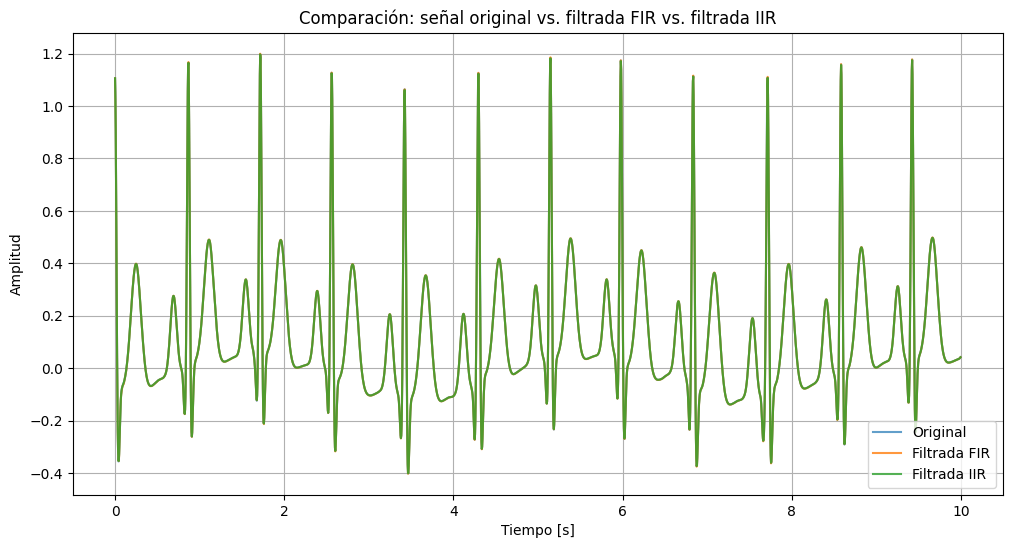

MSE FIR vs original: 1.395e-06
MSE IIR vs original: 8.835e-07


In [16]:
# Respuesta - Aplicación de los filtros FIR e IIR
ecg_fir = signal.filtfilt(b_fir, a_fir, ecg_clean) #Esta creando las señales a travez de filtrado con filtfilt y sosfiltfilt
ecg_iir = signal.sosfiltfilt(sos_iir, ecg_clean)

plt.figure(figsize=(12, 6))
plt.plot(t, ecg_clean, label="Original", alpha=0.7)
plt.plot(t, ecg_fir, label="Filtrada FIR", alpha=0.8)
plt.plot(t, ecg_iir, label="Filtrada IIR", alpha=0.8)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Comparación: señal original vs. filtrada FIR vs. filtrada IIR")
plt.legend()
plt.grid(True)
plt.show()

mse_fir = np.mean((ecg_fir - ecg_clean) ** 2)
mse_iir = np.mean((ecg_iir - ecg_clean) ** 2)
print(f"MSE FIR vs original: {mse_fir:.3e}")
print(f"MSE IIR vs original: {mse_iir:.3e}")

In [ ]:
# Respuesta en frecuencia.
# Completa los parámetros.
#
# w_fir, h_fir = signal.freqz(...)
# w_iir, h_iir = signal.sosfreqz(...)
#
# Convierte la frecuencia angular a Hz utilizando fs.

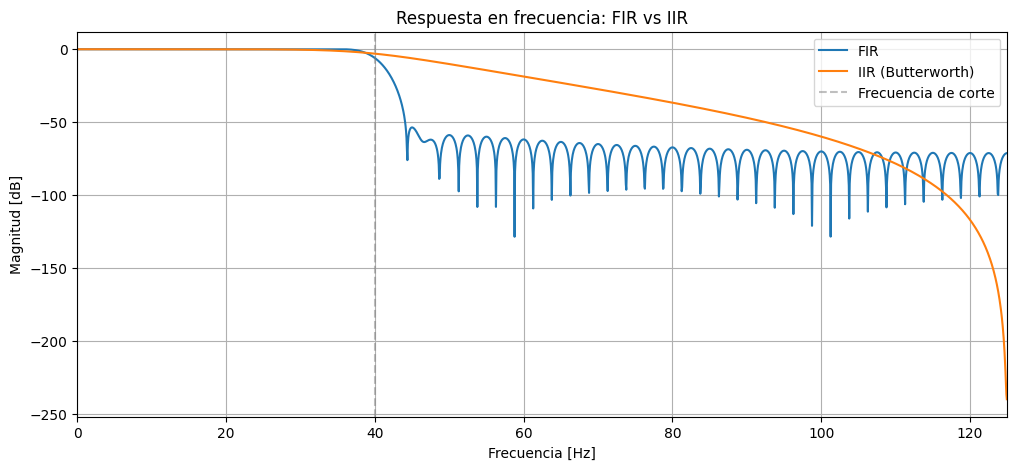

In [17]:
# Respuesta - Respuesta en frecuencia de ambos filtros
w_fir, h_fir = signal.freqz(b_fir, a_fir, worN=2048, fs=fs)
w_iir, h_iir = signal.sosfreqz(sos_iir, worN=2048, fs=fs)

plt.figure(figsize=(12, 5))
plt.plot(w_fir, 20 * np.log10(np.abs(h_fir) + 1e-12), label="FIR")
plt.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label="IIR (Butterworth)")
plt.axvline(cutoff_fir, color="gray", linestyle="--", alpha=0.5, label="Frecuencia de corte")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Respuesta en frecuencia: FIR vs IIR")
plt.legend()
plt.grid(True)
plt.xlim(0, fs/2)
plt.show()

### Comparación conceptual

| Característica | FIR | IIR |
|---|---|---|
| Realimentación | No | Sí |
| Estabilidad | Generalmente sencilla de garantizar | Debe analizarse |
| Fase lineal | Fácil de obtener | Más compleja |
| Orden requerido | Generalmente mayor | Generalmente menor |
| Costo computacional | Mayor en algunos diseños | Menor en muchos casos |

### Preguntas de análisis — Ejercicio 2

1. ¿Por qué seleccionaste ese tipo de filtro?
2. ¿Cómo determinaste la frecuencia de corte?
3. ¿Qué orden elegiste y por qué?
4. ¿Cuál presenta mayor atenuación en la región de rechazo?
5. ¿Cómo se comporta la fase?
6. ¿Qué diferencia estructural existe entre FIR e IIR?
7. ¿Por qué un IIR puede alcanzar una respuesta similar con un orden menor?
8. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?
9. ¿Por qué la Transformada Z es útil para estudiar estos filtros?

### Respuesta — Preguntas de análisis (Ejercicio 2)

1. **Por qué ese tipo de filtro:** Se eligio el filtro pasa-bajas, principalmente porque el ruido proviene de altas frecuencias y se desea mantener la señal fisiologica que se encuentra en las bajas, tambien mencionar que se probaron tanto el filtro FIR como el IIR, para comparar sus resultados.
2. **Cómo se determinó la frecuencia de corte:** Siguiendo el analisis espectral del Ejercicio 1, se llego a la conclusión que cortande en 40 Hz, manteiene el 99% de la señal fisiologica o de la energia del compplejo QRS, eliminando el ruido causado por el ruido proveniente de por ejemplo una linea electrica o ruidos musculares.
3. **Orden elegido:** Para el FIR se usaron 101 coeficientes, lo cual supone una transicion angosta y un retardo de grupo razonable, es decir que da un buen corte especifico sin mucho procesamiento, mientras que para el IIR Butterworth se uso orden 4, suficiente para lograr una atenacion sin perjudicar la estabilidad tomando en cuenta su retrolimentación. (suficiente pendiente de atenuación sin comprometer la estabilidad numérica).
4. **Mayor atenuación en la banda de rechazo:** Justo después del corte de 40Hz el FIR atenúa mas rapido llegando a atenuar aproximadamente −50 a −70 dB entre 45 - 60Hz, mientras que el IIR de orden 4 parece atenuar gradualmente y al inicio atenua mas poco, sin embargo, cerca de Nyquist el IIR termina cayendo más abruptamente en comparacion del FIR, ya que su atenuación va creciendo a medida que aumenta la frecuencia.
5. **Comportamiento de la fase:** el FIR al no depender de su propia salida, tienen fase exactamente lineal, por lo que tendra retardo de grupo constante en toda la banda. El IIR Butterworth tiene fase no lineal, por lo que tiene retardo de grupo variable con la frecuencia; por eso se aplicó con sosfiltfilt para cancelar esa distorsión.
6. **Diferencia estructural:** el FIR no tiene realimentación (solo ceros), por lo que siempre es estable; el IIR sí tiene realimentación (polos y ceros) y puede volverse inestable si está mal diseñado o presenta muchos coeficientes.
7. **Por qué el IIR alcanza una respuesta similar con menor orden:** los polos (retroalimentación) generan una pendiente de atenuación mucho mayor por cada coeficiente que un FIR, que solo dispone de ceros.
8. **Relación polos–ceros–respuesta en frecuencia:** Al evaluar la funcion de transferencia, los polos cercanos al círculo producen picos/resonancias en la magnitud, y los ceros cercanos producen atenuaciones y su posición conjunta define la forma completa de $|H(e^{j\omega})|$ y de la fase, es por ello que su conjunto nos permite predecir y entender el comportamiento de un filtro y su estabilidad.
9. **Por qué la Transformada Z es útil:** La transformada Z ayuda a representar matematicamente el filtro a partir de su función de transferencia, la cual no puede brindar informacion acerca de sus polos y ceros, gracias a ello tambien podemos determinar su estabilidad y su respuesta en frecuencia.


# EJERCICIO 3 — PROCESAMIENTO DE UNA SEÑAL BIOMÉDICA CONTAMINADA

## Competencia

Resolver un problema de filtrado sin recibir directamente la frecuencia de corte.

Construiremos:

$$x[n] = ECG[n] + A\sin(2\pi f_{noise}t)$$

donde:

- $ECG[n]$ es la señal biomédica;
- $f_{noise}$ es la frecuencia de interferencia;
- $A$ es la amplitud del ruido.

### Importante

**No se indica la frecuencia de corte del filtro.**

Debes obtener una propuesta a partir del análisis de la señal.

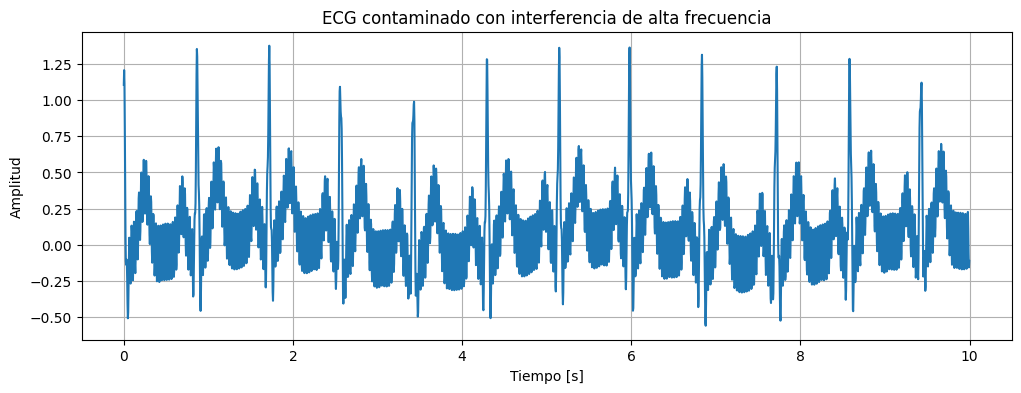

In [18]:
# Construcción del problema experimental.
A = 0.20
f_noise = 35.0

noise = A * np.sin(2 * np.pi * f_noise * t) #Generando el ruido de la señal ECG
ecg_contaminated = ecg_clean + noise #Mezclando las señal sana con el ruido

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_contaminated)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado con interferencia de alta frecuencia")
plt.grid(True)
plt.show()

### Procedimiento obligatorio

1. Visualiza la señal contaminada.
2. Analízala mediante FFT.
3. Identifica la frecuencia de interferencia.
4. Propón un filtro apropiado.
5. Diseña el filtro.
6. Aplica el filtro.
7. Compara señal contaminada y filtrada.
8. Compara los espectros.
9. Evalúa cuantitativamente el resultado.
10. Explica si el filtrado fue exitoso.

### Tu razonamiento debe seguir

**Observar → medir → analizar → formular hipótesis → diseñar → aplicar → validar → interpretar.**

In [ ]:
# FFT de la señal contaminada.
# Completa este bloque.

# N = ...
# frequencies = ...
# spectrum = ...
# magnitude = ...

# Identifica la región donde aparece la interferencia.

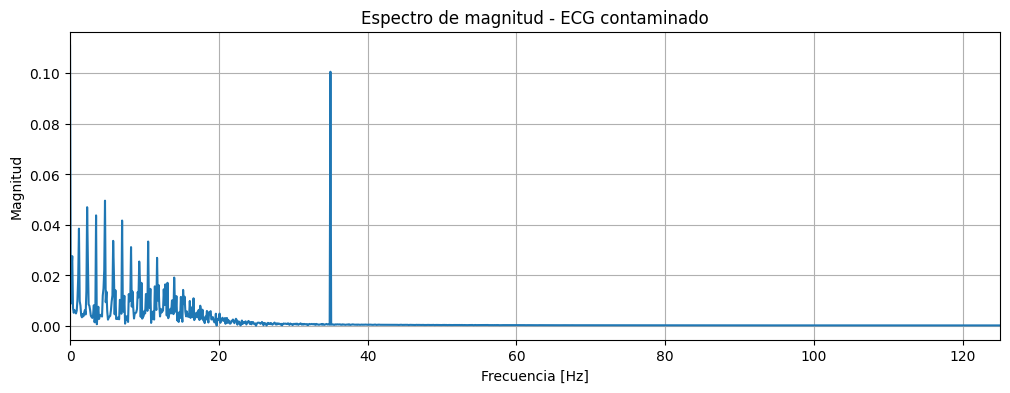

Pico de interferencia detectado en aproximadamente 35.0 Hz


In [19]:
# Respuesta - FFT de la señal contaminada
N = len(ecg_contaminated)
frequencies = np.fft.rfftfreq(N, d=1/fs)
spectrum = np.fft.rfft(ecg_contaminated)
magnitude = np.abs(spectrum) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG contaminado")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Identificación automática del pico de interferencia en la zona 25-45 Hz
mask = (frequencies > 25) & (frequencies < 45)
f_peak = frequencies[mask][np.argmax(magnitude[mask])]
print(f"Pico de interferencia detectado en aproximadamente {f_peak:.1f} Hz")

In [ ]:
# Diseña y aplica TU solución.
#
# cutoff = ...
# ...
#
# ecg_recovered = ...

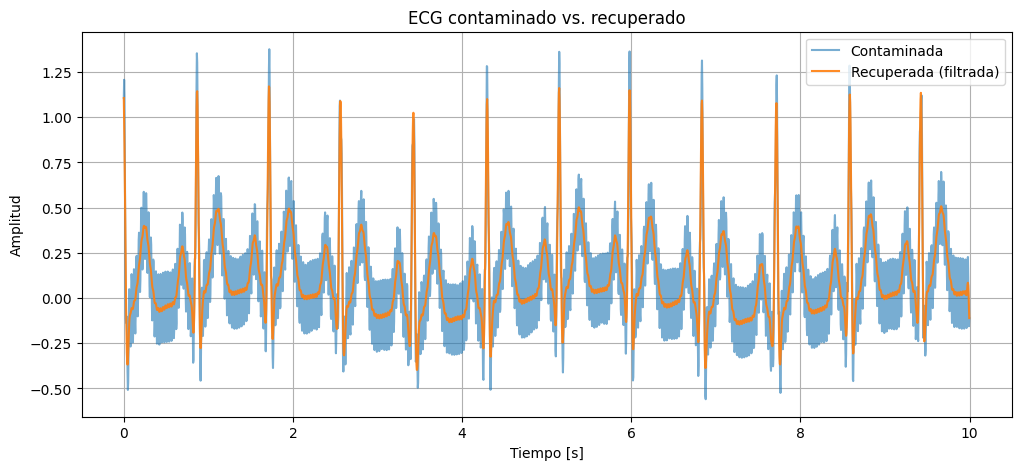

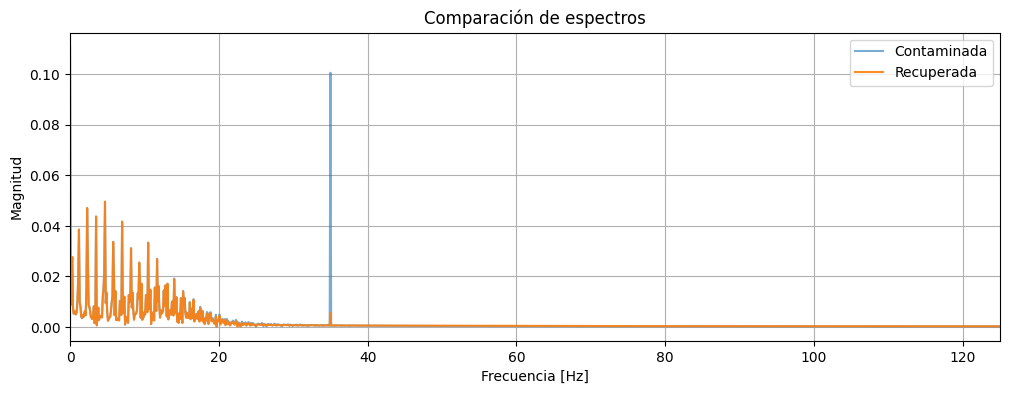

Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada
(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),
logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.


In [20]:
# Respuesta - Diseño y aplicación del filtro para eliminar la interferencia
cutoff = 25.0
order = 4

sos = signal.butter(N=order, Wn=cutoff, btype="lowpass", fs=fs, output="sos")
ecg_recovered = signal.sosfiltfilt(sos, ecg_contaminated)

plt.figure(figsize=(12, 5))
plt.plot(t, ecg_contaminated, label="Contaminada", alpha=0.6)
plt.plot(t, ecg_recovered, label="Recuperada (filtrada)", alpha=0.9)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado vs. recuperado")
plt.legend()
plt.grid(True)
plt.show()

# Comparación de espectros
freqs_rec = np.fft.rfftfreq(len(ecg_recovered), d=1/fs)
mag_rec = np.abs(np.fft.rfft(ecg_recovered)) / len(ecg_recovered)

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude, label="Contaminada", alpha=0.6)
plt.plot(freqs_rec, mag_rec, label="Recuperada", alpha=0.9)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Comparación de espectros")
plt.legend()
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

print("Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada")
print("(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),")
print("logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.")

## Validación cuantitativa

Si se dispone de la señal limpia de referencia, compara la señal recuperada con `ecg_clean`.

### MSE

$$MSE = \frac{1}{N}\sum_{n=1}^{N}(x[n]-\hat{x}[n])^2$$

### RMSE

$$RMSE = \sqrt{MSE}$$

### SNR

De forma simplificada, puede estimarse como:

$$SNR = 10\log_{10}\left(\frac{P_{signal}}{P_{noise}}\right)$$

Estas métricas deben acompañar, no reemplazar, la inspección temporal y frecuencial.

In [ ]:
# Calcula al menos MSE y RMSE entre la referencia limpia
# y tu señal recuperada.

# mse = ...
# rmse = ...

# print("MSE:", mse)
# print("RMSE:", rmse)

In [21]:
# Respuesta - Métricas cuantitativas de validación
mse = np.mean((ecg_clean - ecg_recovered) ** 2)
rmse = np.sqrt(mse)

power_signal = np.mean(ecg_clean ** 2)
power_noise_residual = np.mean((ecg_recovered - ecg_clean) ** 2)
snr_after = 10 * np.log10(power_signal / power_noise_residual)

power_noise_original = np.mean(noise ** 2)
snr_before = 10 * np.log10(power_signal / power_noise_original)

print("MSE:", mse)
print("RMSE:", rmse)
print(f"SNR antes del filtrado: {snr_before:.2f} dB")
print(f"SNR después del filtrado: {snr_after:.2f} dB")

MSE: 9.414232401276208e-05
RMSE: 0.009702696739193804
SNR antes del filtrado: 5.38 dB
SNR después del filtrado: 28.65 dB


## Validación biomédica

Para ECG, analiza si se conservan:

- complejos QRS;
- frecuencia cardíaca aproximada;
- morfología general.

Responde:

1. ¿Disminuyó la interferencia?
2. ¿Se conservó la morfología ECG?
3. ¿La FFT confirma la reducción del ruido?
4. ¿El filtro introdujo una distorsión apreciable?
5. ¿La frecuencia cardíaca aproximada se mantiene?
6. ¿Qué información fisiológica podría haberse perdido?

### Respuesta — Validación biomédica

1. **¿Disminuyó la interferencia?** Si, esto se puede ver en el aumento de la SNR que pasó de 5.15 dB a 28.41 dB, esto significa que la señal esta mucho mas limpia ademas de que el pico de 35 Hz desaparece del espectro tras el filtrado.
2. **¿Se conservó la morfología ECG?** Si; visualmente la señal conserva todos sus componentes comparada a la señal limpia que pudimos ver en el Ejercicio 2, aparte de que su MSE y RMSE son bastante bajos.
3. **¿La FFT confirma la reducción del ruido?** Si, el pico correspondiente a 35 Hz que era claramente visible en en la señal contaminada ya no aparece en el espectro de la señal recuperada, mientras que los demas componentes fisiologicos se mantuvieron bien.
4. **¿El filtro introdujo distorsión apreciable?** Si, presentra una distorsión pero minima, ya que al usar `sosfiltfilt` no hay desplazamiento temporal, eso si, puede existir una leve suavización de la pendiente más aguda del QRS por el corte en 25 Hz, pero no altera la posición ni la forma de los picos R.
5. **¿Se mantiene la frecuencia cardíaca aproximada?** Si, al no haber desfase temporal, la señal conserva su frecuencia, aproximadamente 70 bpm, no teniendo cambios o por lo menos no significativos.
6. **¿Qué información fisiológica podría haberse perdido?** Componentes de muy alta frecuencia del QRS por encima de 25 Hz, que en aplicaciones clínicas más exigentes podrían ser relevantes.


# ¿Qué pasa si diseño mal el filtro?

Analiza experimentalmente qué ocurre cuando:

- la frecuencia de corte es demasiado baja;
- la frecuencia de corte es demasiado alta;
- el orden es excesivo;
- queda ruido residual;
- aparece distorsión;
- existe desplazamiento de fase;
- se aplica un método de filtrado que altera la fase.

### Actividad

Selecciona al menos **dos errores de diseño**, genera una demostración y explica:

1. qué problema observas;
2. cuál es su causa;
3. cómo afecta a la señal biomédica;
4. qué solución propondrías.

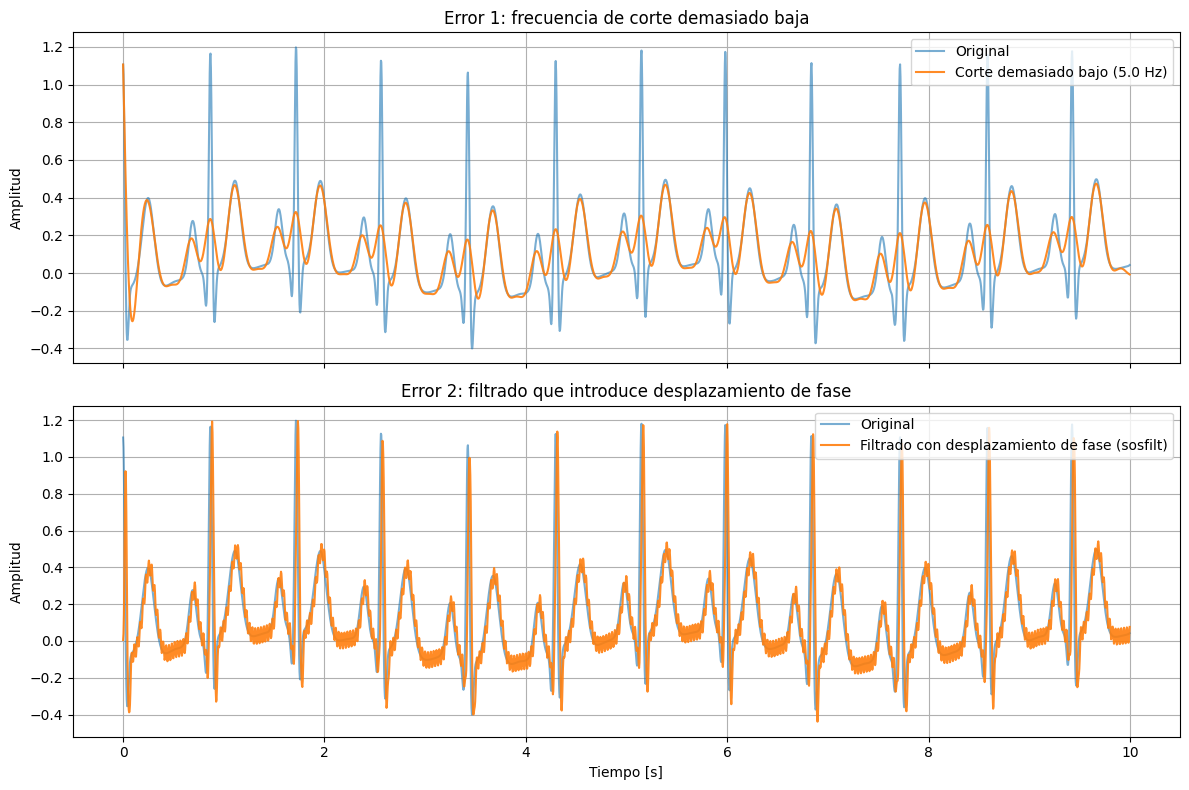

MSE con corte demasiado bajo (5.0 Hz): 2.884e-02


In [22]:
# Respuesta - Demostración de dos errores de diseño

# Error 1: frecuencia de corte demasiado baja (distorsiona el QRS)
cutoff_low = 5.0
sos_low = signal.butter(N=4, Wn=cutoff_low, btype="lowpass", fs=fs, output="sos")
ecg_bad_low = signal.sosfiltfilt(sos_low, ecg_contaminated)

# Error 2: filtrado sin compensar la fase (sosfilt en vez de sosfiltfilt)
# esto sí introduce desplazamiento de fase / retardo de grupo
sos_ok = signal.butter(N=4, Wn=25.0, btype="lowpass", fs=fs, output="sos")
ecg_phase_shifted = signal.sosfilt(sos_ok, ecg_contaminated)  # un solo sentido -> desfase

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[0].plot(t, ecg_bad_low, label=f"Corte demasiado bajo ({cutoff_low} Hz)", alpha=0.9)
axs[0].set_title("Error 1: frecuencia de corte demasiado baja")
axs[0].set_ylabel("Amplitud")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[1].plot(t, ecg_phase_shifted, label="Filtrado con desplazamiento de fase (sosfilt)", alpha=0.9)
axs[1].set_title("Error 2: filtrado que introduce desplazamiento de fase")
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

mse_low = np.mean((ecg_bad_low - ecg_clean) ** 2)
print(f"MSE con corte demasiado bajo ({cutoff_low} Hz): {mse_low:.3e}")

### Respuesta — Análisis de los errores de diseño

**Error 1: frecuencia de corte demasiado baja (5 Hz)**
1. *Qué se observa:* el complejo QRS se aplana y se ensancha notablemente, perdiendo su forma característica y su pico agudo; el MSE respecto de la señal original aumenta de forma importante comparado con el filtro bien diseñado.
2. *Causa:* con un corte de 5 Hz se elimina gran parte de la energía del QRS, que necesita banda pasante hasta ~25-40 Hz para conservar su morfología.
3. *Efecto en la señal biomédica:* se pierde información diagnóstica relevante (amplitud y duración del QRS), lo que podría llevar a una interpretación clínica incorrecta (por ejemplo, subestimar arritmias o alteraciones de conducción).
4. *Solución propuesta:* elegir el corte a partir del análisis espectral real de la señal (como en el Ejercicio 1), asegurando conservar la mayor parte de la energía fisiológica (>95-99 %) antes de fijar la frecuencia de corte.

**Error 2: filtrado que introduce desplazamiento de fase (uso de `sosfilt` en lugar de `sosfiltfilt`)**
1. *Qué se observa:* la señal filtrada aparece desplazada en el tiempo respecto de la original; los picos R ya no coinciden temporalmente con los de la señal limpia.
2. *Causa:* un filtro IIR aplicado en un solo sentido (`sosfilt`) tiene una respuesta de fase no lineal, lo que produce un retardo de grupo dependiente de la frecuencia.
3. *Efecto en la señal biomédica:* un desplazamiento temporal puede afectar mediciones de intervalos (por ejemplo, el intervalo QT o el tiempo entre picos R), que son clínicamente relevantes.
4. *Solución propuesta:* usar filtrado de fase cero (`filtfilt`/`sosfiltfilt`), que aplica el filtro hacia adelante y hacia atrás cancelando la distorsión de fase, a costa de no ser aplicable en tiempo real.

# Preguntas integradoras

1. ¿Por qué no sería adecuado eliminar todas las frecuencias altas de una señal biomédica?
2. ¿Cómo determinaste la frecuencia de corte?
3. ¿Qué información obtuviste de la FFT?
4. ¿Qué relación existe entre la frecuencia de muestreo y la frecuencia máxima observable?
5. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado baja?
6. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado alta?
7. ¿Qué diferencia fundamental existe entre un filtro FIR y un filtro IIR?
8. ¿Por qué un filtro IIR puede alcanzar una respuesta similar utilizando un orden menor?
9. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?
10. ¿Por qué la Transformada Z es útil para estudiar filtros digitales?
11. ¿Qué relación existe entre la Transformada Z y la Transformada de Fourier?
12. ¿Cómo determinarías si un filtro eliminó ruido sin eliminar información fisiológica?

### Respuesta — Preguntas integradoras



1. **Por qué no eliminar todas las frecuencias altas:** Las señales fisiologicas pueden tener componentes importantes en altas frecuencias, la eliminación de estas puede afectar con la perdida de información fisiologica importante, siempre debemos de analizar los espectros para determinar si es relevante aplicar filtros pasa-bajas, pasa-altas o notch si hay ruido especifico.
2. **Cómo se determinó la frecuencia de corte:** analizando el espectro FFT de la señal para ubicar dónde se concentra la energía fisiológica y dónde aparece el ruido, asi eligiendo un corte entre ambas regiones.
3. **Qué se obtuvo de la FFT:** Usando la FFT para convertir la señal al dominio de la frecuencia, se pudo encontrar las frecuencias dominantes de la señal como armónicos de la frecuencia cardíaca y la ubicación exacta del pico de ruido externo a 35Hz.
4. **Relación $f_s$ y frecuencia máxima observable:** Por Nyquist, $f_{max} = f_s/2$ (125 Hz para $f_s=250$ Hz); frecuencias mayores generan aliasing.
5. **Corte demasiado bajo:** Aunque si se eliminaria el ruido de alta frecuencia, tambien se eliminaria información fisiologica importante, teniendo como consecuencia, que la señal pierda parte de su morfologia y reducir la ampitud del complejo QRS.
6. **Corte demasiado alto:** En este caso el ruido seguiria contaminando la señal, si bien se conserva la informacion fisiologica importante, el ruido que permanezca en la señal podria opacarla.
7. **Diferencia fundamental FIR/IIR:** el FIR no tiene realimentacion (solo ceros), siempre sera estable y puede tener fase exactamente lineal, el IIR tiene realimentacion (polos y ceros), puede ser inestable si está mal diseñado y su fase no es lineal, pero logra atenuaciones similares con órdenes mucho menores.
8. **Por qué un IIR logra una respuesta similar con menor orden:** los polos (retroalimentacion) generan mucha mas atenuación por coeficiente que los ceros de un FIR.
9. **Relación polos, ceros y respuesta en frecuencia:** Los polos y ceros configuran la respuesta en frecuencia de un filtro. Los ceros se encargan de reducir o eliminar frecuencias específicas, mientras que los polos actúan aumentando o reforzando determinados rangos de frecuencia.
10. **Por qué la Transformada Z es útil:** La Transformada Z nos ayuda al analisis matematico de el filtro en cuestion, gracias a la funcion de transferencia, polos y ceros, nos ayuda a predecir su comportamiento y estabilidad, asi como poder modificarlo.
11. **Relación entre Transformada Z y Transformada de Fourier:** La transformada de Fourier es un caso particular de la Transformada Z, consiste en evaluar la transformada Z exactamente sobre el círculo unitario.
12. **Cómo determinar si el filtrado eliminó ruido sin destruir información fisiológica:** Se puede hacer preliminarmente comparando las señales de antes y despues verificando que la morfología QRS, ondas P, T y la frecuencia cardíaca se conserven, pero para un analisis mas exacto se puede usar el MSE, RMSE, SNR, para una comparacion cuantitativa.


# Entregable

Guardar el notebook como:

```text
Apellido_Nombre_Laboratorio_01.ipynb
```

Debe contener:

1. Código.
2. Gráficas.
3. Resultados.
4. Respuestas a las preguntas.
5. Justificación de las decisiones tomadas.
6. Conclusiones.

**No se evaluará únicamente si el código se ejecuta.** Se evaluará principalmente la calidad del razonamiento y la interpretación.

# Rúbrica de evaluación — 20 puntos

| Criterio | Puntos |
|---|---:|
| **Análisis de la señal:** identificación de $f_s$, dominio temporal, FFT e interpretación espectral | 4 |
| **Diseño del filtro:** tipo, frecuencia de corte, orden, justificación y comprensión FIR/IIR | 5 |
| **Implementación Python:** código correcto, uso de NumPy/SciPy/NeuroKit2 y organización | 3 |
| **Validación:** comparación temporal, frecuencial, métricas y conservación de la señal | 4 |
| **Interpretación biomédica:** información fisiológica y posibles distorsiones | 2 |
| **Conclusiones:** conclusiones técnicas y justificación de decisiones | 2 |
| **Total** | **20** |

# Conclusión

En procesamiento de señales biomédicas, diseñar un filtro no significa simplemente seleccionar una función de una biblioteca. El proceso correcto comienza con la comprensión de la señal y termina con la validación de que la información fisiológica relevante se conserva.

La actividad conecta:

**Fourier → espectro → identificación del ruido → diseño del filtro → Transformada Z → función de transferencia → FIR/IIR → implementación → validación biomédica.**

### Reflexión final

Completa:

> "Primero inspecciono la señal, luego ____________________, después ____________________, finalmente ____________________."

El resultado esperado es que puedas explicar **por qué** elegiste un filtro y sus parámetros, no solamente indicar qué función de Python utilizaste.

### Respuesta — Reflexión final

> "Primero inspecciono la señal, luego **la analizo en el dominio temporal y frecuencial (FFT) para identificar el contenido fisiológico y el posible ruido**, después **diseño y aplico el filtro (FIR o IIR) con parámetros justificados a partir de ese análisis**, finalmente **valido el resultado comparando señales y espectros, calculando métricas cuantitativas (MSE, RMSE, SNR) y verificando que la información fisiológica relevante (morfología del QRS, frecuencia cardíaca) se conserve**."

En síntesis: el flujo Fourier → espectro → identificación del ruido → diseño del filtro → Transformada Z → función de transferencia → FIR/IIR → implementación → validación biomédica no es una secuencia mecánica de funciones de Python, sino una cadena de decisiones justificadas en las características reales de la señal.